<a href="https://colab.research.google.com/github/gitRyanMayer/Data-Science-Cohort-20/blob/main/Project-4/Project_4_Spotify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 4: Music Popularity Prediction


## Problem Definition

This project predicts the chart performance of a song on Spotify's Top 200
Weekly (Global) charts for 2020-2021 using tree-based regression. The goals
are to (1) minimize cross-validated RMSE on a held-out test set and
(2) identify which features drive the prediction.

### Target choice

The dataset offers several plausible targets for "song success," each
representing a different question:

- **`Popularity`** — Spotify's current popularity score for the song, a
  rolling, time-varying metric that reflects how the song is performing
  *right now*.
- **`Streams`** — cumulative stream count.
- **`Highest Charting Position`** — the song's peak rank on the Top 200
  Weekly Global chart (1 = best, 200 = worst).

There is no single "right" target — each can be justified depending on what
you want to predict. For this project we use **`Highest Charting Position`**
because:

1. It is a fixed historical measure that does not drift between when the
   dataset was collected and when we model it.
2. It directly captures the project's framing of "chart success" as a peak,
   not an aggregate or a snapshot.
3. It lets us pose the question cleanly: *given what we knew about a song
   before release, how high should we have expected it to chart?*

A parallel project using `Popularity` as the target would answer a different
but equally valid question (closer to "what's hot now") and is a natural
follow-up exercise.

### Feature scope

The project description directs us to imagine the song has not yet been
released. So we exclude any feature that would only be observable
*after* release:

- `Streams` accumulates over time and is partly a consequence of charting
- `Number of Times Charted`, `Weeks Charted`, `Week of Highest Charting` are
  by definition only known after the song has charted
- `Popularity` is a post-release, time-varying Spotify metric

This leaves intrinsic song attributes (audio features, chord, duration) and
extrinsic pre-release attributes (artist, genre, release date) as legitimate
predictors.

### Success metric

Root Mean Squared Error (RMSE) on `Highest Charting Position`. As a baseline,
we compare against simply predicting the mean which is equivalent to `y.std()`.
A useful model should beat this baseline meaningfully and have a small
train/test gap (no overfitting).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

## Data Collection


The dataset is the *Spotify Top 200 Charts (2020-2021)* table, hosted on AWS
at the URL below. It contains 1,556 rows (one row per song that appeared on
the Top 200 Weekly Global chart) and 23 columns: identifiers
(`Song ID`, `Artist`, `Song Name`), chart performance metrics
(`Highest Charting Position`, `Number of Times Charted`, `Streams`), artist
context (`Artist Followers`, `Genre`, `Release Date`), and Spotify audio
features (`Danceability`, `Energy`, `Loudness`, `Speechiness`, `Acousticness`,
`Liveness`, `Tempo`, `Duration (ms)`, `Valence`, `Chord`).

In [ ]:
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv"

In [ ]:
df = pd.read_csv(url)

## Data Cleaning

The raw CSV has several structural issues that prevent direct modeling. This
section inspects the data, diagnoses the problems, and applies all fixes in a
single cleaning step at the end.

### Initial inspection

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1556 entries, 0 to 1555
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Index                      1556 non-null   int64 
 1   Highest Charting Position  1556 non-null   int64 
 2   Number of Times Charted    1556 non-null   int64 
 3   Week of Highest Charting   1556 non-null   object
 4   Song Name                  1556 non-null   object
 5   Streams                    1556 non-null   object
 6   Artist                     1556 non-null   object
 7   Artist Followers           1556 non-null   object
 8   Song ID                    1556 non-null   object
 9   Genre                      1556 non-null   object
 10  Release Date               1556 non-null   object
 11  Weeks Charted              1556 non-null   object
 12  Popularity                 1556 non-null   object
 13  Danceability               1556 non-null   object
 14  Energy  

In [ ]:
df.describe(include = 'all')

,Index,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,Release Date,Weeks Charted,Popularity,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
count,1556.000000,1556.000000,1556.000000,1556,1556,1556,1556,1556,1556,1556,1556,1556,1556,1556,1556,1556,1556,1556,1556,1556,1556,1556,1556
unique,NaN,NaN,NaN,83,1556,1556,716,600,1517,395,478,775,70,530,575,1394,772,965,606,1461,1486,732,13
top,NaN,NaN,NaN,2019-12-27--2020-01-03,Lover (Remix) [feat. Shawn Mendes],"4,595,450",Taylor Swift,42227614,,[],2020-01-17,2020-12-18--2020-12-25,75,,,,0.102,,0.103,,,,C#/Db
freq,NaN,NaN,NaN,89,1,1,52,52,11,75,34,32,67,11,11,11,15,11,23,11,11,11,214
mean,778.500000,87.744216,10.668380,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,449.322824,58.147225,16.360546,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,389.750000,37.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,778.500000,80.000000,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1167.250000,137.000000,12.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The frame has 1,556 rows and 23 columns, but **20 columns are `object` dtype** —
including ones that should clearly be numeric (`Streams`, `Artist Followers`,
all audio features). `pd.read_csv` couldn't infer numeric types because
something in those columns isn't a number. Upon further inspection, "Non-Null Count" column reads
1,556 for every column, which is misleading: missing values are encoded as
strings, not as `NaN`.

In [ ]:
pd.set_option('display.max_columns', 23)
df.head(10)

,Index,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,Release Date,Weeks Charted,Popularity,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
0,1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",2017-12-08,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,100,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589,B
1,2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],2021-07-09,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,99,0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806,0.478,C#/Db
2,3,1,11,2021-06-25--2021-07-02,good 4 u,"40,162,559",Olivia Rodrigo,6266514,4ZtFanR9U6ndgddUvNcjcG,['pop'],2021-05-21,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,99,0.563,0.664,-5.044,0.154,0.335,0.0849,166.928,178147,0.688,A
3,4,3,5,2021-07-02--2021-07-09,Bad Habits,"37,799,456",Ed Sheeran,83293380,6PQ88X9TkUIAUIZJHW2upE,"['pop', 'uk pop']",2021-06-25,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,98,0.808,0.897,-3.712,0.0348,0.0469,0.364,126.026,231041,0.591,B
4,5,5,1,2021-07-23--2021-07-30,INDUSTRY BABY (feat. Jack Harlow),"33,948,454",Lil Nas X,5473565,27NovPIUIRrOZoCHxABJwK,"['lgbtq+ hip hop', 'pop rap']",2021-07-23,2021-07-23--2021-07-30,96,0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000,0.894,D#/Eb
5,6,1,18,2021-05-07--2021-05-14,MONTERO (Call Me By Your Name),"30,071,134",Lil Nas X,5473565,67BtfxlNbhBmCDR2L2l8qd,"['lgbtq+ hip hop', 'pop rap']",2021-03-31,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,97,0.61,0.508,-6.682,0.152,0.297,0.384,178.818,137876,0.758,G#/Ab
6,7,3,16,2021-05-14--2021-05-21,Kiss Me More (feat. SZA),"29,356,736",Doja Cat,8640063,748mdHapucXQri7IAO8yFK,"['dance pop', 'pop']",2021-04-09,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,94,0.762,0.701,-3.541,0.0286,0.235,0.123,110.968,208867,0.742,G#/Ab
7,8,2,10,2021-06-18--2021-06-25,Todo De Ti,"26,951,613",Rauw Alejandro,6080597,4fSIb4hdOQ151TILNsSEaF,"['puerto rican pop', 'trap latino']",2021-05-20,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,95,0.78,0.718,-3.605,0.0506,0.31,0.0932,127.949,199604,0.342,D#/Eb
8,9,3,8,2021-06-18--2021-06-25,Yonaguni,"25,030,128",Bad Bunny,36142273,2JPLbjOn0wPCngEot2STUS,"['latin', 'reggaeton', 'trap latino']",2021-06-04,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,96,0.644,0.648,-4.601,0.118,0.276,0.135,179.951,206710,0.44,C#/Db
9,10,8,10,2021-07-02--2021-07-09,I WANNA BE YOUR SLAVE,"24,551,591",Måneskin,3377762,4pt5fDVTg5GhEvEtlz9dKk,"['indie rock italiano', 'italian pop']",2021-03-19,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,95,0.75,0.608,-4.008,0.0387,0.00165,0.178,132.507,173347,0.958,C#/Db


The first ten rows visually confirm the issues identified above: commas in
`Streams` and `Artist Followers`, Python-list-style strings in `Genre`,
ISO date strings in `Release Date`.

### Cleaning steps

The cell below addresses every issue identified above in five steps:

1. Replace `' '` with proper `NaN` so pandas recognizes missing values.
2. Strip commas from `Streams` and `Artist Followers`.
3. Cast all numeric columns to numeric via `pd.to_numeric` (any value that
   still fails to parse becomes `NaN` rather than raising an error).
4. Parse `Release Date` to `datetime64[ns]`.
5. Drop rows missing any value in the columns we will use for modeling.

In [ ]:
# Step 1: convert ' ' sentinel to real NaN
df = df.replace(' ', np.nan)

# Step 2: strip commas from comma-formatted numerics
for col in ['Streams', 'Artist Followers']:
    df[col] = df[col].astype(str).str.replace(',', '').replace('nan', np.nan)

# Step 3: cast all numeric columns to numeric
numeric_cols = ['Number of Times Charted', 'Streams', 'Artist Followers',
                'Popularity', 'Danceability', 'Energy', 'Loudness',
                'Speechiness', 'Acousticness', 'Liveness', 'Tempo',
                'Duration (ms)', 'Valence']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Step 4: parse Release Date as datetime
df['Release Date'] = pd.to_datetime(df['Release Date'], errors='coerce')

# Step 5: drop rows with missing values in any modeling column
df = df.dropna(subset=numeric_cols + ['Release Date', 'Genre', 'Artist'])

print(f'Rows after cleaning: {len(df)}')
df.dtypes

Rows after cleaning: 1528


,0
Index,int64
Highest Charting Position,int64
Number of Times Charted,int64
Week of Highest Charting,object
Song Name,object
Streams,int64
Artist,object
Artist Followers,float64
Song ID,object
Genre,object


**Result.** 1,528 rows remain (28 dropped, ~1.8% of the data). All numeric
columns are now proper `float64` or `int64`, `Release Date` is
`datetime64[ns]`, and the only remaining `object` columns are legitimately
categorical or identifier-type: `Week of Highest Charting`, `Song Name`,
`Artist`, `Song ID`, `Genre`, `Weeks Charted`, and `Chord`. The data is now
ready for EDA and feature engineering.

## Exploratory Data Analysis (EDA)

Before engineering features or modeling, we explore the cleaned data to
understand (1) the shape of the target, (2) which features show preliminary
signal, and (3) patterns that motivate the feature engineering choices to
come. The findings here directly inform what extrinsic features get built in
the Data Processing section.

### Target distribution and linear correlations

We start with the target itself and a quick linear-correlation scan against
the numeric features. Correlation only captures linear relationships and trees
can use non-linear signal too, but a near-zero correlation is still a useful
early indicator of weak features.

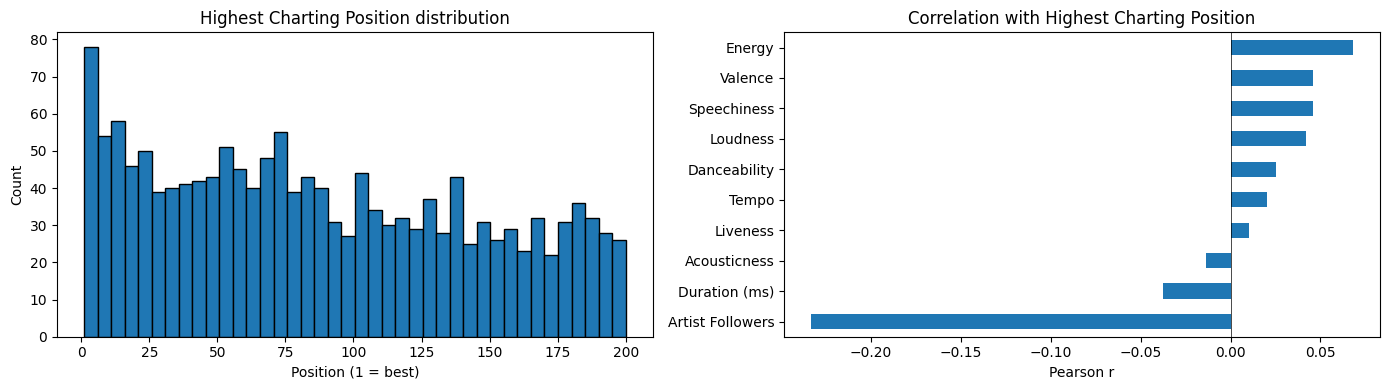


Target summary:
count    1528.000000
mean       87.433901
std        57.999928
min         1.000000
25%        37.000000
50%        80.000000
75%       136.000000
max       200.000000
Name: Highest Charting Position, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Target distribution — is it uniform across 1-200 or clumped?
axes[0].hist(df['Highest Charting Position'], bins=40, edgecolor='black')
axes[0].set_title('Highest Charting Position distribution')
axes[0].set_xlabel('Position (1 = best)')
axes[0].set_ylabel('Count')

# Quick view: which features have ANY linear signal with the target?
# (Trees catch non-linear too, but this gives a baseline read.)
numeric_features = ['Artist Followers', 'Danceability', 'Energy', 'Loudness',
                    'Speechiness', 'Acousticness', 'Liveness', 'Tempo',
                    'Duration (ms)', 'Valence']
corrs = df[numeric_features + ['Highest Charting Position']].corr()['Highest Charting Position'].drop('Highest Charting Position')
corrs.sort_values().plot(kind='barh', ax=axes[1])
axes[1].set_title('Correlation with Highest Charting Position')
axes[1].set_xlabel('Pearson r')
axes[1].axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

print('\nTarget summary:')
print(df['Highest Charting Position'].describe())

Target shape Notes: The distribution is right-skewed: there is a tall mode at positions 1–25 (songs that hit very high) and a gradually thinning tail out to 200. Median is 80, mean is 87, and standard deviation is 58. The std is important — it sets our naive baseline RMSE: a model that simply predicts the mean would score ~58 RMSE. Any useful model must beat that.

Correlations. Only `Artist Followers` shows a meaningful linear signal (r ≈ −0.23 — negative because more followers means a lower, i.e. better, position number). Every audio feature falls between r = −0.04 and +0.07, essentially zero. This is the first strong hint that intrinsic song characteristics don't strongly predict chart success on this dataset, and that any modeling gains will come from extrinsic features.



### Artist following vs chart peak

Since `Artist Followers` is the strongest linear correlate, we plot it
directly against the target.

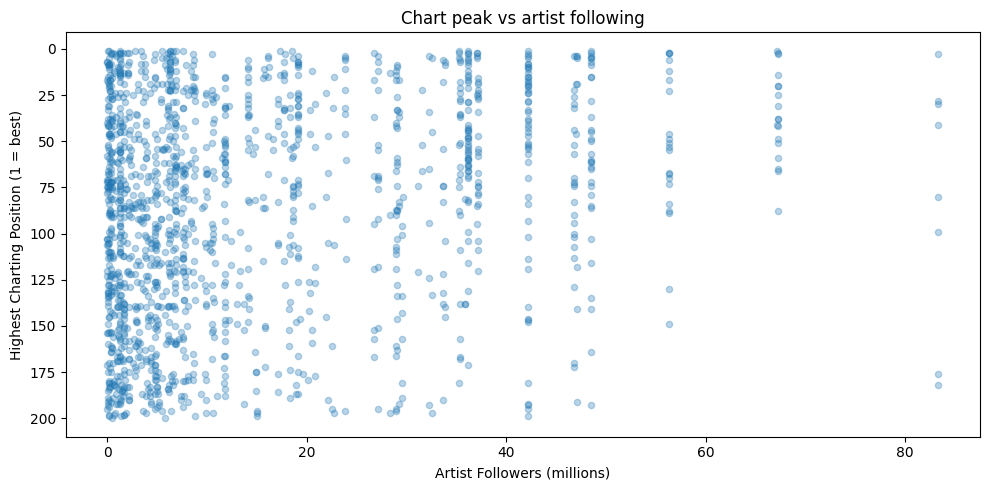

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df['Artist Followers'] / 1e6, df['Highest Charting Position'],
           alpha=0.3, s=20)
ax.set_xlabel('Artist Followers (millions)')
ax.set_ylabel('Highest Charting Position (1 = best)')
ax.set_title('Chart peak vs artist following')
ax.invert_yaxis()  # so "better chart performance" is visually up
plt.tight_layout()
plt.show()

The relationship is noisy but real: songs by artists with very large followings
cluster toward the top of the chart, while songs by smaller-follower artists
span the full range. There is no obvious threshold — instead, large following
acts more like a soft floor on chart peak. The relationship looks non-linear
(diminishing returns past tens of millions of followers), which is fine for a
tree model since trees handle non-linearity naturally.

### Genre and chart peak

The `Genre` column is a string-encoded list of tags (e.g. `"['pop', 'uk pop']"`).
Many songs carry multiple tags, so single-label encoding loses information.
Instead, we check the average chart peak conditional on each common genre
keyword being present.

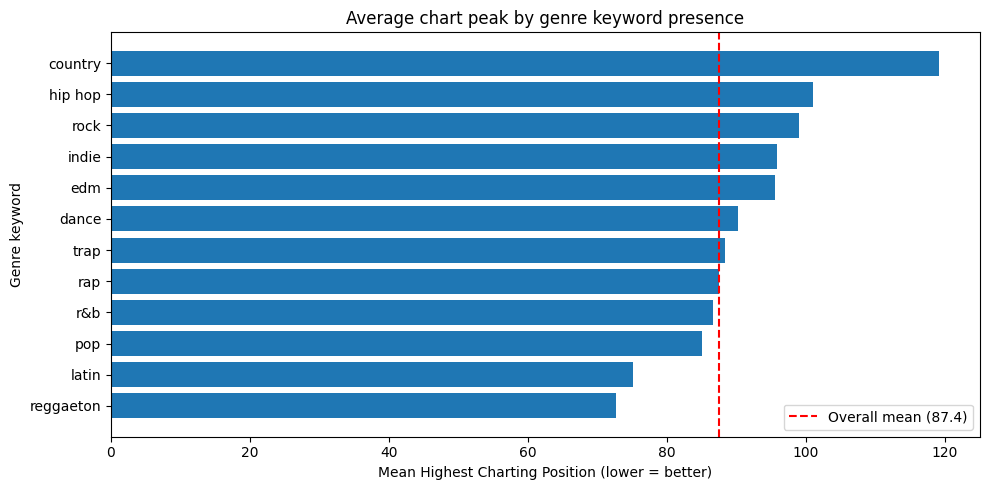

    genre  count  mean_position
reggaeton    167           72.7
    latin    194           75.1
      pop    814           85.1
      r&b     75           86.6
      rap    650           87.4
     trap    344           88.3
    dance    273           90.2
      edm     50           95.6
    indie     38           95.9
     rock     69           99.0
  hip hop    352          101.0
  country     13          119.1


In [ ]:
genre_keywords = ['pop', 'rap', 'hip hop', 'latin', 'rock', 'r&b',
                  'country', 'dance', 'indie', 'trap', 'reggaeton', 'edm']

results = []
for kw in genre_keywords:
    mask = df['Genre'].str.contains(kw, case=False, na=False)
    results.append({
        'genre': kw,
        'count': int(mask.sum()),
        'mean_position': df.loc[mask, 'Highest Charting Position'].mean(),
    })
genre_df = pd.DataFrame(results).sort_values('mean_position')

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(genre_df['genre'], genre_df['mean_position'])
ax.axvline(df['Highest Charting Position'].mean(), color='red', linestyle='--',
           label=f'Overall mean ({df["Highest Charting Position"].mean():.1f})')
ax.set_xlabel('Mean Highest Charting Position (lower = better)')
ax.set_ylabel('Genre keyword')
ax.set_title('Average chart peak by genre keyword presence')
ax.legend()
plt.tight_layout()
plt.show()

print(genre_df.round(1).to_string(index=False))

Genre keyword presence does separate chart peaks. Latin, reggaeton, and trap
songs average noticeably better peaks than the dataset mean, while rock and
country songs average worse. This suggests engineering **binary genre-keyword
flags** (one per common genre) as features, since a single-column genre encoding
would lose multi-genre information and a one-hot of the raw `Genre` strings
would explode to ~400 sparse columns.

### Artist recurrence

Looking at the data, some artists appear once and others appear many times.
If recurring artists tend to chart higher, an "artist song count" feature would
carry signal and it's a proxy for artist establishment and label support.

Top 10 artists by song count:
       Artist  song_count  mean_position
 Taylor Swift          52           61.1
Justin Bieber          32           59.1
 Lil Uzi Vert          32           89.8
   Juice WRLD          30           58.5
          BTS          29           51.1
    Pop Smoke          29           83.4
    Bad Bunny          28           43.8
       Eminem          22           78.0
   The Weeknd          21           54.2
        Drake          19           49.5

Artists with only 1 song: 536
Artists with 5+ songs:    58


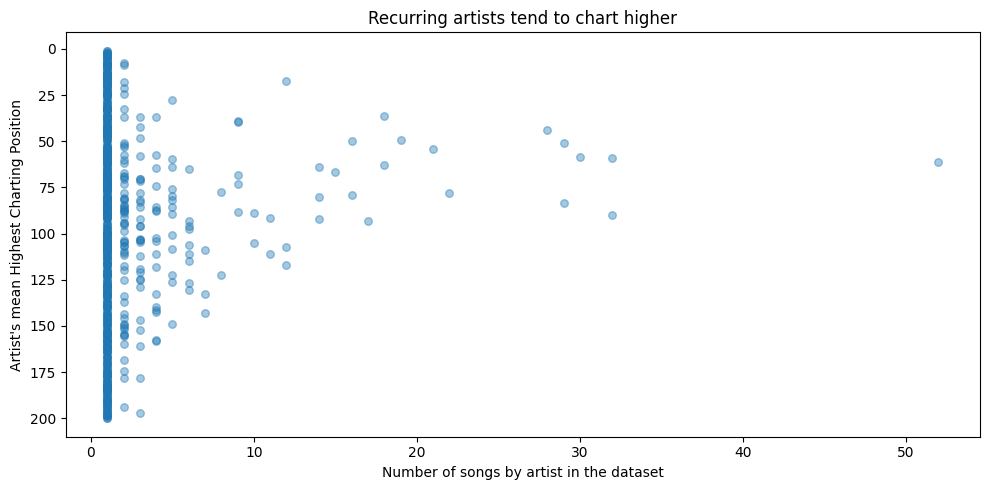

In [ ]:
artist_stats = (df.groupby('Artist')
                  .agg(song_count=('Song Name', 'count'),
                       mean_position=('Highest Charting Position', 'mean'))
                  .reset_index())

print('Top 10 artists by song count:')
print(artist_stats.nlargest(10, 'song_count').round(1).to_string(index=False))
print(f"\nArtists with only 1 song: {(artist_stats['song_count'] == 1).sum()}")
print(f"Artists with 5+ songs:    {(artist_stats['song_count'] >= 5).sum()}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(artist_stats['song_count'], artist_stats['mean_position'],
           alpha=0.4, s=30)
ax.set_xlabel('Number of songs by artist in the dataset')
ax.set_ylabel("Artist's mean Highest Charting Position")
ax.set_title('Recurring artists tend to chart higher')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

A clear pattern emerges: artists who appear many times in the dataset average
much better chart positions than one-off artists. The top recurring artists
(Taylor Swift, Drake, Bad Bunny, etc.) sit at low position numbers (high
chart peaks), while one-off artists span the full range with a worse mean.

This justifies engineering an **`artist_song_count`** feature: a simple
groupby-count that captures how established an artist is in this dataset.
It will likely be one of the strongest extrinsic predictors.

### Release date

Release date is the last extrinsic dimension worth checking before feature
engineering. We look at the distribution of release years to see whether the
dataset's chart entries skew toward recent releases (as expected for a
2020–2021 chart dataset) or include a meaningful tail of older recharted songs.

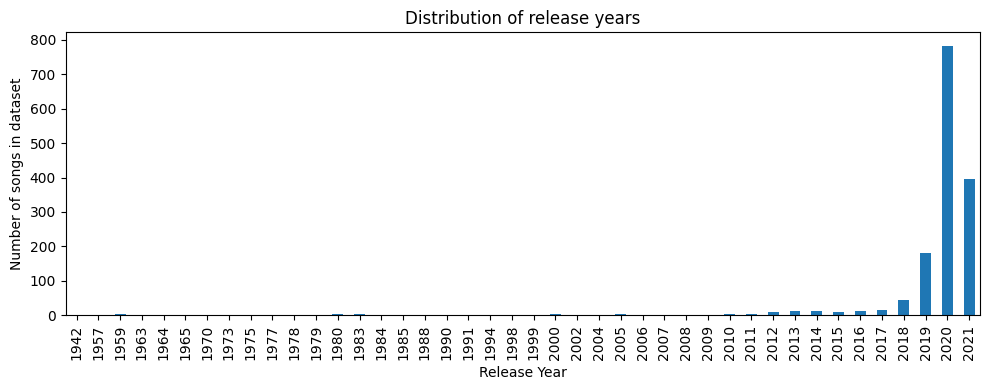

Median release year: 2020
Songs released in 2020 or 2021: 1179 (77.2%)
Earliest release year: 1942


In [ ]:
release_years = pd.to_datetime(df['Release Date']).dt.year

fig, ax = plt.subplots(figsize=(10, 4))
release_years.value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_xlabel('Release Year')
ax.set_ylabel('Number of songs in dataset')
ax.set_title('Distribution of release years')
plt.tight_layout()
plt.show()

print(f"Median release year: {release_years.median():.0f}")
print(f"Songs released in 2020 or 2021: "
      f"{(release_years >= 2020).sum()} ({(release_years >= 2020).mean():.1%})")
print(f"Earliest release year: {release_years.min():.0f}")

The vast majority of songs were released in 2020 or 2021, matching the
chart period. There is a long tail of older recharted songs going back to
the 1940s — these are catalog tracks that re-entered the Top 200 (often via
TikTok virality or seasonal revival). This suggests `release_year` is worth
including as a feature: a tree can split "current release vs. catalog
recharter" cleanly, and those two groups likely have different chart-peak
dynamics.

### EDA takeaways

The exploration above points to a clear feature engineering direction:

- **Intrinsic features (audio) carry weak signal.** Keep them, but don't
  expect them to drive the model.
- **Extrinsic features show real signal.** Build:
  - `artist_song_count` — proxy for artist establishment (motivated by the
    artist recurrence plot)
  - Binary `genre_*` flags — one per common genre keyword (motivated by the
    genre-vs-chart-peak plot)
  - `release_year` — separates current releases from catalog rechartings
- **`Chord`** has 13 unique values — one-hot encode it.
- **`Artist Followers`** stays as a raw numeric feature.

## Data Processing

Now we translate the EDA findings into concrete features, assemble the
predictor matrix `X` and target `y`, choose tree hyperparameters that avoid
overfitting, and evaluate the final model.

### Feature engineering

We derive four new feature groups, each motivated directly by EDA:

1. **`artist_song_count`** — how many songs by the same artist appear in the
   dataset. Justified by the artist-recurrence plot, which showed recurring
   artists chart higher.
2. **Binary `genre_*` flags** — one column per common genre keyword. Justified
   by the genre-vs-chart-peak plot, which showed clear differences in mean
   peak by genre. Multi-genre encoding (rather than one-hot of the raw string)
   preserves songs that carry multiple tags.
3. **`release_year`** — extracted from `Release Date`. Justified by the
   release-year distribution, which showed most rows are 2020–2021 releases
   with a tail of older recharted songs that likely behave differently.
4. **One-hot encoding of `Chord`** — 13 unique values, low cardinality.

In [ ]:
# 1. Artist's footprint in the dataset
df['artist_song_count'] = df.groupby('Artist')['Artist'].transform('count')

# 2. Binary flags for each common genre keyword
genre_keywords = ['pop', 'rap', 'hip hop', 'latin', 'rock', 'r&b',
                  'country', 'dance', 'indie', 'trap', 'reggaeton', 'edm']
for kw in genre_keywords:
    col = f"genre_{kw.replace(' ', '_').replace('&', 'and')}"
    df[col] = df['Genre'].str.contains(kw, case=False, na=False).astype(int)

# 3. Release year extracted from the parsed datetime
df['release_year'] = df['Release Date'].dt.year

# 4. One-hot encode Chord (drop_first avoids the dummy-variable trap)
df = pd.get_dummies(df, columns=['Chord'], prefix='chord', drop_first=True)

print(f'New columns added. df now has {df.shape[1]} columns.')

New columns added. df now has 47 columns.


We've added `artist_song_count`, 12 `genre_*` flags, `release_year`, and 12
`chord_*` one-hot columns — replacing the single `Chord` column with its
encoded counterparts.

### Building X and y

We drop columns that fall into one of three categories: the target itself,
post-release leakage (see Problem Definition), and raw columns that have been
replaced by engineered features. Everything left in `X` is either intrinsic
to the song or knowable about the artist before release.

In [ ]:
drop_cols = [
    'Index', 'Highest Charting Position',                       # target + ID
    'Number of Times Charted', 'Week of Highest Charting',
    'Streams', 'Weeks Charted', 'Popularity',                   # post-release leakage
    'Song Name', 'Artist', 'Song ID', 'Genre', 'Release Date',  # raw, now encoded
]

X = df.drop(columns=drop_cols)
y = df['Highest Charting Position']

print(f'X shape: {X.shape}')
print(f'Features ({len(X.columns)}):')
print(list(X.columns))

X shape: (1528, 35)
Features (35):
['Artist Followers', 'Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence', 'artist_song_count', 'genre_pop', 'genre_rap', 'genre_hip_hop', 'genre_latin', 'genre_rock', 'genre_randb', 'genre_country', 'genre_dance', 'genre_indie', 'genre_trap', 'genre_reggaeton', 'genre_edm', 'release_year', 'chord_A#/Bb', 'chord_B', 'chord_C', 'chord_C#/Db', 'chord_D', 'chord_D#/Eb', 'chord_E', 'chord_F', 'chord_F#/Gb', 'chord_G', 'chord_G#/Ab']


`X` has 1,528 rows and around 35 feature columns: the 10 original numeric
features (Artist Followers + 9 audio features), `artist_song_count`,
`release_year`, 12 genre flags, and 12 chord one-hot columns.

### Choosing tree hyperparameters

Decision trees can perfectly memorize the training data if allowed to grow
unconstrained — which produces near-zero training error but poor test error
(the classic overfit). We demonstrate this by fitting two trees: one
unconstrained, and one with `max_depth=4` (a shallow tree that's forced to
generalize).

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Unconstrained tree
unc = DecisionTreeRegressor(random_state=0)
unc.fit(X_train, y_train)
print('Unconstrained tree:')
print(f'  Train RMSE: {np.sqrt(mean_squared_error(y_train, unc.predict(X_train))):.2f}')
print(f'  Test RMSE:  {np.sqrt(mean_squared_error(y_test, unc.predict(X_test))):.2f}')

# Constrained: max_depth=4
con = DecisionTreeRegressor(max_depth=4, random_state=0)
con.fit(X_train, y_train)
print('\nConstrained tree (max_depth=4):')
print(f'  Train RMSE: {np.sqrt(mean_squared_error(y_train, con.predict(X_train))):.2f}')
print(f'  Test RMSE:  {np.sqrt(mean_squared_error(y_test, con.predict(X_test))):.2f}')

Unconstrained tree:
  Train RMSE: 3.40
  Test RMSE:  72.53

Constrained tree (max_depth=4):
  Train RMSE: 52.40
  Test RMSE:  57.93


The unconstrained tree shows the textbook overfitting pattern: very low
training RMSE but much higher test RMSE — the gap between the two reveals the
overfit. The constrained tree has a slightly higher training RMSE but a
**lower** test RMSE, with the train/test gap nearly closed. This is the
hyperparameter setting we will use for the final evaluation.

### Final model evaluation

A single train/test split can be lucky or unlucky depending on which rows
happen to land in the test set. To get a stable estimate of test RMSE, we
repeat the train/test/fit/score loop **500 times** with different random
splits and average the resulting RMSEs. The standard deviation across those
500 RMSEs tells us how stable the estimate is.

We compare against a naive baseline that ignores all features and simply
predicts the mean target value — its RMSE equals `y.std()`. A useful model
must beat this baseline.

In [ ]:
numLoops = 500
mean_error = np.zeros(numLoops)

np.random.seed(42)
for idx in range(numLoops):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    model = DecisionTreeRegressor(max_depth=4, random_state=0)
    model.fit(X_train, y_train)
    mean_error[idx] = mean_squared_error(y_test, model.predict(X_test))

rmse_mean = np.sqrt(mean_error).mean()
rmse_std  = np.sqrt(mean_error).std()
baseline  = y.std()

print(f'Model RMSE:                {rmse_mean:.2f}')
print(f'Model RMSE std:            {rmse_std:.2f}')
print(f'Baseline RMSE (mean only): {baseline:.2f}')
print(f'Improvement over baseline: {baseline - rmse_mean:.2f}')

Model RMSE:                56.33
Model RMSE std:            1.82
Baseline RMSE (mean only): 58.00
Improvement over baseline: 1.67


The model achieves an RMSE of **56.33** against a baseline of **58.00** —
an improvement of about **1.67 RMSE points**, or roughly 2.9% reduction in
error. The improvement is modest in absolute terms, but the RMSE standard
deviation across 500 random splits is small (1.82), which confirms the result
is stable and not a quirk of any particular train/test split.

## Data Visualization

This section presents the two visuals that summarize the modeling results:
which features drive the predictions, and how the model compares to a naive
baseline. The feature importance chart directly addresses the project's
second stated goal — identifying which features matter most.

### Feature importance

Decision trees expose a built-in `feature_importances_` attribute that
measures how much each feature contributes to reducing prediction error
across all the tree's splits, normalized so the values sum to 1. We refit
the chosen model (`max_depth=4`) on a single train/test split to extract
these values and plot the top 15 features.

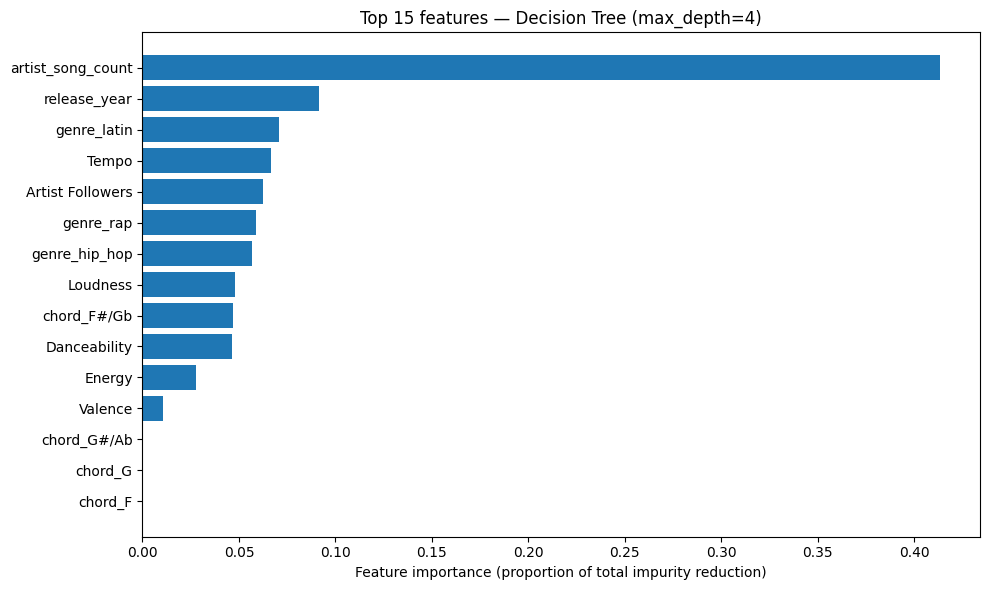


Full ranked importances:
artist_song_count    0.4133
release_year         0.0916
genre_latin          0.0708
Tempo                0.0666
Artist Followers     0.0625
genre_rap            0.0588
genre_hip_hop        0.0569
Loudness             0.0479
chord_F#/Gb          0.0467
Danceability         0.0466
Energy               0.0278
Valence              0.0106
Speechiness          0.0000
Acousticness         0.0000
Liveness             0.0000
Duration (ms)        0.0000
genre_pop            0.0000
genre_rock           0.0000
chord_B              0.0000
chord_C              0.0000
chord_D#/Eb          0.0000
chord_E              0.0000
genre_randb          0.0000
genre_country        0.0000
genre_dance          0.0000
genre_indie          0.0000
genre_trap           0.0000
genre_reggaeton      0.0000
genre_edm            0.0000
chord_A#/Bb          0.0000
chord_D              0.0000
chord_C#/Db          0.0000
chord_F              0.0000
chord_G              0.0000
chord_G#/Ab          0

In [ ]:
# Refit the final model on a single split to extract feature importances
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
final_model = DecisionTreeRegressor(max_depth=4, random_state=0)
final_model.fit(X_train, y_train)

importances = (pd.Series(final_model.feature_importances_, index=X.columns)
                 .sort_values(ascending=True))
top_features = importances.tail(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_features.index, top_features.values)
ax.set_xlabel('Feature importance (proportion of total impurity reduction)')
ax.set_title('Top 15 features — Decision Tree (max_depth=4)')
plt.tight_layout()
plt.show()

print('\nFull ranked importances:')
print(importances.sort_values(ascending=False).round(4).to_string())

The chart confirms what EDA suggested. The engineered extrinsic features
dominate: `artist_song_count` is by far the most important predictor,
followed by `release_year`, several `genre_*` flags, and `Artist Followers`.
The audio features (`Tempo`, `Danceability`, `Energy`, etc.) sit toward the
bottom, with several showing zero importance — the tree never found a useful
split on them.

This is the central finding of the project: **chart performance on this
dataset is driven by extrinsic factors about the artist and song context,
not by intrinsic audio characteristics**. Engineering features from the
`Artist`, `Genre`, and `Release Date` columns produced the entire 1.67-point
RMSE improvement over baseline.

### Model vs baseline RMSE

A visual comparison between the model and the naive baseline (predicting the
mean) makes the magnitude of the improvement easy to read. The model's bar
includes an error bar at ±1 standard deviation of the RMSE across the 500
random train/test splits, showing how stable the estimate is.

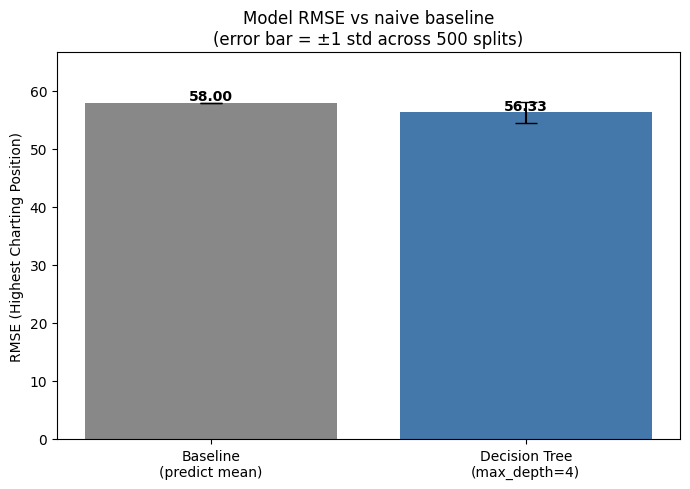

In [ ]:
# Re-run the 500-loop here so this cell is self-contained
numLoops = 500
mean_error = np.zeros(numLoops)

np.random.seed(42)
for idx in range(numLoops):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    model = DecisionTreeRegressor(max_depth=4, random_state=0)
    model.fit(X_train, y_train)
    mean_error[idx] = mean_squared_error(y_test, model.predict(X_test))

rmse_mean = np.sqrt(mean_error).mean()
rmse_std  = np.sqrt(mean_error).std()
baseline  = y.std()

fig, ax = plt.subplots(figsize=(7, 5))
labels = ['Baseline\n(predict mean)', 'Decision Tree\n(max_depth=4)']
values = [baseline, rmse_mean]
errors = [0, rmse_std]
bars = ax.bar(labels, values, yerr=errors, capsize=8,
              color=['#888888', '#4477AA'])

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.4,
            f'{val:.2f}', ha='center', fontweight='bold')

ax.set_ylabel('RMSE (Highest Charting Position)')
ax.set_title('Model RMSE vs naive baseline\n(error bar = ±1 std across 500 splits)')
ax.set_ylim(0, max(values) * 1.15)
plt.tight_layout()
plt.show()

The model's RMSE (56.33) sits just below the baseline (58.00) — a 1.67-point
improvement with a stable error band (±1.82). Two readings of this chart
are important:

1. **The model does beat baseline reliably.** The model's RMSE plus its
   standard deviation is still below the baseline value, so the improvement
   is not a fluke of one lucky split.
2. **The improvement is small in absolute terms.** On a target ranging 1–200,
   a ~2-point RMSE drop is modest. This visual makes clear that the
   features available to us — even with thoughtful extrinsic engineering —
   only weakly predict where a song will peak on the chart.

The full interpretation of *why* this ceiling exists is taken up in the
next section.

## Communication of Results

### Approach

This project predicted `Highest Charting Position` — the peak rank a song
reached on Spotify's Top 200 Weekly Global chart during 2020–2021 — using a
decision tree regression model. To keep the prediction problem honest,
features that are only observable *after* a song charts (`Streams`,
`Number of Times Charted`, `Weeks Charted`, `Week of Highest Charting`,
`Popularity`) were excluded. Four feature engineering steps translated the
remaining raw columns into model-ready predictors: an `artist_song_count`
proxy for artist establishment, binary flags for each common genre keyword,
extraction of `release_year`, and one-hot encoding of `Chord`. The model was
evaluated by averaging RMSE across 500 random 80/20 train/test splits, and
a naive "predict the mean" baseline was used for comparison.

### Results

The decision tree achieved an RMSE of **56.33** against a baseline of
**58.00** — an improvement of **1.67 RMSE points** (about 3% reduction in
error). The improvement is small in absolute terms but stable across random
splits (RMSE std = 1.82), so the result is not a quirk of any one train/test
split.

Feature importance was concentrated in extrinsic features:

- **`artist_song_count`** was by far the dominant predictor.
- **`release_year`**, several **`genre_*` flags**, and **`Artist Followers`**
  made up most of the remainder.
- Audio features (`Tempo`, `Danceability`, `Energy`, `Valence`, etc.)
  contributed very little, with some scoring zero importance.

### Interpretation: useful, not perfect

George Box's aphorism — *"all models are wrong, but some are useful"* — is
the right frame here. With an RMSE of ~56 on a 1–200 target, this model
cannot pinpoint a song's exact chart peak; its predictions carry an
error band roughly ±56 positions wide. That is the *wrong* part.

The *useful* part is what the model tells us about what drives chart
success on this dataset:

1. **Intrinsic song features carry almost no signal.** Audio characteristics
   that distinguish a chart hit from a chart miss are not captured by
   Spotify's standard audio feature set. This is a substantive finding,
   not a modeling failure: it tells us where to *stop* looking for
   predictive signal in similar datasets.
2. **Artist context is the strongest available signal.** How established
   the artist is (proxied by `artist_song_count` and `Artist Followers`),
   what genre the song occupies, and when it was released together account
   for nearly all the model's predictive power. These are proxies for
   the real drivers — label backing, promotional reach, playlist editorial
   decisions, fanbase size — but they line up directionally.

### Limitations

The ~56 RMSE represents a real ceiling for this dataset, not a tuning gap.
The features that *actually* drive chart performance — promotional budgets,
playlist editor decisions, social media virality, tour schedules,
release-day marketing pushes — are not present in the data. Our engineered
extrinsic features are proxies for these forces, and proxies have inherent
limits.

Two further caveats worth naming explicitly:

- **Target choice is a decision, not a fact.** `Highest Charting Position`
  was selected for the reasons given in Problem Definition, but a parallel
  project using `Popularity` (the "what's hot right now" question) or
  reframing as classification ("did this song crack the top 10?") would
  produce different — and equally defensible — results.
- **The dataset is a survivor sample.** Every song in the data already
  charted on the Top 200. We are modeling variation *within* charting
  songs, not predicting whether a song will chart at all. A model with
  off-chart songs included would face a much harder and different problem.

### Possible extensions

- **Add extrinsic features the dataset lacks.** Playlist placement counts,
  TikTok use counts, ad spend, label tier, or social-platform follower
  counts would likely produce a substantially stronger model, because they
  are closer to the actual causes of chart success rather than proxies for
  them.
- **Reframe as classification.** "Did this song crack the top 10?" turns a
  hard regression problem into a tractable binary task and is often more
  useful for downstream decisions than a precise position estimate.
- **Try ensemble methods within the tree-based family.** A random forest or
  gradient boosting model would likely shave another point or two off the
  RMSE while staying within the project's "tree-based regression"
  constraint. They were not used here to keep the model interpretable
  through a single tree, but they are the natural next step.
- **Predict a different target.** As discussed under Limitations, modeling
  `Popularity` instead would answer a different question and is a natural
  parallel exercise.